# Read LiveOcean Layers Icechunk Store

Opens the virtual Icechunk store created by `layers_icechunk.ipynb` in xarray.

In [1]:
import os
import icechunk
import xarray as xr

In [2]:
os.environ['AWS_REQUEST_CHECKSUM_CALCULATION'] = 'when_required'
os.environ['AWS_RESPONSE_CHECKSUM_VALIDATION'] = 'when_required'

In [3]:
storage_endpoint = "https://s3.kopah.uw.edu"
storage_bucket   = "liveocean-pmacc"
storage_name     = "icechunk-test-2"
bucket_url       = f"s3://{storage_bucket}"

In [4]:
storage = icechunk.s3_storage(
    bucket=storage_bucket,
    prefix=f"icechunk/{storage_name}",
    from_env=True,
    endpoint_url=storage_endpoint,
    region='not-used',
    force_path_style=True,
)

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket_url}/",
        store=icechunk.s3_store(
            region="not-used",
            anonymous=False,
            s3_compatible=True,
            force_path_style=True,
            endpoint_url=storage_endpoint,
        ),
    )
)

credentials = icechunk.containers_credentials(
    {f"{bucket_url}/": icechunk.s3_credentials(anonymous=False)}
)

repo = icechunk.Repository.open(
    storage, config, authorize_virtual_chunk_access=credentials
)
session = repo.readonly_session("main")
print(repo)

<icechunk.Repository (v2)>
storage:
    <icechunk.Storage>
    type: S3 (native)
    bucket: liveocean-pmacc
    prefix: icechunk/icechunk-test-2
    region: not-used
    endpoint_url: https://s3.kopah.uw.edu
    force_path_style: True
config: <RepositoryConfig ...>



In [5]:
ds = xr.open_zarr(session.store, consolidated=False, chunks={})
ds

<xarray.Dataset> Size: 101GB
Dimensions:          (ocean_time: 49, s_w: 31, eta_rho: 1302, xi_rho: 663,
                      tracer: 14, s_rho: 30, boundary: 4, eta_v: 1301,
                      xi_v: 663, eta_u: 1302, xi_u: 662, eta_psi: 1301,
                      xi_psi: 662)
Coordinates:
  * ocean_time       (ocean_time) datetime64[ns] 392B 2026-01-01 ... 2026-01-03
  * s_w              (s_w) float64 248B -1.0 -0.9667 -0.9333 ... -0.03333 0.0
    lat_rho          (eta_rho, xi_rho) float64 7MB dask.array<chunksize=(651, 332), meta=np.ndarray>
    lon_rho          (eta_rho, xi_rho) float64 7MB dask.array<chunksize=(651, 332), meta=np.ndarray>
  * s_rho            (s_rho) float64 240B -0.9833 -0.95 ... -0.05 -0.01667
    lat_v            (eta_v, xi_v) float64 7MB dask.array<chunksize=(651, 332), meta=np.ndarray>
    lon_v            (eta_v, xi_v) float64 7MB dask.array<chunksize=(651, 332), meta=np.ndarray>
    lon_u            (eta_u, xi_u) float64 7MB dask.array<chunksize=(651, 331), meta=np.ndarray>
    lat_u            (eta_u, xi_u) float64 7MB dask.array<chunksize=(651, 331), meta=np.ndarray>
    lon_psi          (eta_psi, xi_psi) float64 7MB dask.array<chunksize=(651, 331), meta=np.ndarray>
    lat_psi          (eta_psi, xi_psi) float64 7MB dask.array<chunksize=(651, 331), meta=np.ndarray>
Dimensions without coordinates: eta_rho, xi_rho, tracer, boundary, eta_v, xi_v,
                                eta_u, xi_u, eta_psi, xi_psi
Data variables: (12/163)
    AKs              (ocean_time, s_w, eta_rho, xi_rho) float32 5GB dask.array<chunksize=(1, 8, 434, 221), meta=np.ndarray>
    Akk_bak          float64 8B ...
    Akp_bak          float64 8B ...
    Akv_bak          float64 8B ...
    AttSW            float64 8B ...
    AttChl           float64 8B ...
    ...               ...
    wetdry_mask_psi  (ocean_time, eta_psi, xi_psi) float32 169MB dask.array<chunksize=(1, 1301, 662), meta=np.ndarray>
    wetdry_mask_u    (ocean_time, eta_u, xi_u) float32 169MB dask.array<chunksize=(1, 1302, 662), meta=np.ndarray>
    zeta             (ocean_time, eta_rho, xi_rho) float32 169MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    wetdry_mask_rho  (ocean_time, eta_rho, xi_rho) float32 169MB dask.array<chunksize=(1, 1302, 663), meta=np.ndarray>
    zooplankton      (ocean_time, s_rho, eta_rho, xi_rho) float32 5GB dask.array<chunksize=(1, 8, 434, 221), meta=np.ndarray>
    wetdry_mask_v    (ocean_time, eta_v, xi_v) float32 169MB dask.array<chunksize=(1, 1301, 663), meta=np.ndarray>
Attributes: (12/43)
    file:              /gscratch/macc/parker/LO_roms/cas7_t2_x11b/f2026.01.02...
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             LiveOcean input file
    var_info:          /gscratch/macc/parker/LO_roms_source_git/ROMS/External...
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            12x16
    history:           ROMS, Version 4.3, Friday - April 17, 2026 -  5:22:10 PM
    ana_file:          ROMS/Functionals/ana_btflux.h, ROMS/Functionals/ana_st...
    CPP_options:       X11B, ADD_FSOBC, ADD_M2OBC, ANA_BPFLUX, ANA_BSFLUX, AN...
    bio_file:          /gscratch/macc/parker/LO_roms_user/x11b/fennel.h

In [6]:
ds.ocean_time.values

array(['2026-01-01T00:00:00.000000000', '2026-01-01T01:00:00.000000000',
       '2026-01-01T02:00:00.000000000', '2026-01-01T03:00:00.000000000',
       '2026-01-01T04:00:00.000000000', '2026-01-01T05:00:00.000000000',
       '2026-01-01T06:00:00.000000000', '2026-01-01T07:00:00.000000000',
       '2026-01-01T08:00:00.000000000', '2026-01-01T09:00:00.000000000',
       '2026-01-01T10:00:00.000000000', '2026-01-01T11:00:00.000000000',
       '2026-01-01T12:00:00.000000000', '2026-01-01T13:00:00.000000000',
       '2026-01-01T14:00:00.000000000', '2026-01-01T15:00:00.000000000',
       '2026-01-01T16:00:00.000000000', '2026-01-01T17:00:00.000000000',
       '2026-01-01T18:00:00.000000000', '2026-01-01T19:00:00.000000000',
       '2026-01-01T20:00:00.000000000', '2026-01-01T21:00:00.000000000',
       '2026-01-01T22:00:00.000000000', '2026-01-01T23:00:00.000000000',
       '2026-01-02T00:00:00.000000000', '2026-01-02T01:00:00.000000000',
       '2026-01-02T02:00:00.000000000', '2026-01-02

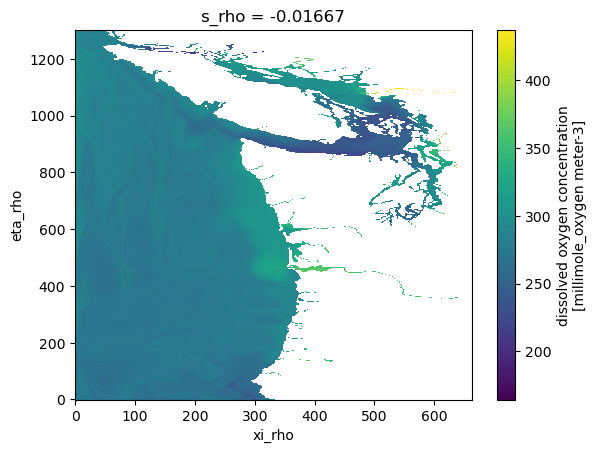

In [7]:
ds.oxygen[:,-1,:,:].mean(dim='ocean_time').plot()

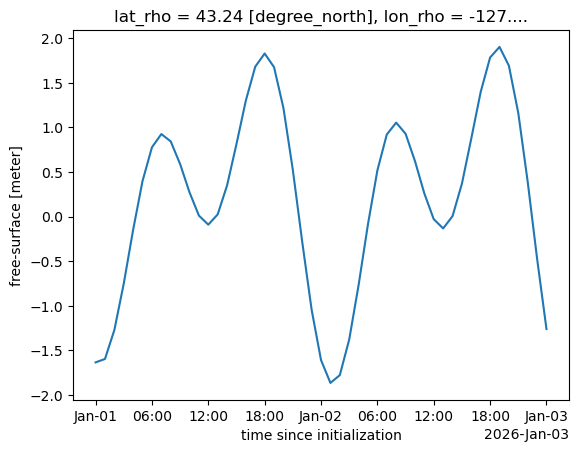

In [8]:
ds.zeta[:,100,100].plot()